# Cluster Analysis in Python

## 1. Libraries and setup

The workflow uses common analytics libraries. A fixed random seed makes the demonstrations reproducible.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist, pdist, squareform

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8.5, 5.5),
    "axes.titleweight": "bold",
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Simple example: observations, similarity, and distance

A computer needs a numerical definition of similarity. For numeric variables, a smaller distance usually means two observations are more alike.

The example below compares Euclidean distance (straight-line distance) and Manhattan distance (movement along horizontal and vertical directions).

In [2]:
toy_points = pd.DataFrame({
    "observation": ["A", "B", "C", "D"],
    "feature_1": [1.0, 1.8, 5.0, 6.2],
    "feature_2": [1.2, 2.0, 4.8, 5.5],
})
toy_points

,observation,feature_1,feature_2
0,A,1.000,1.200
1,B,1.800,2.000
2,C,5.000,4.800
3,D,6.200,5.500


In [3]:
coordinates = toy_points[["feature_1", "feature_2"]]

euclidean_matrix = pd.DataFrame(
    squareform(pdist(coordinates, metric="euclidean")),
    index=toy_points["observation"],
    columns=toy_points["observation"],
)

manhattan_matrix = pd.DataFrame(
    squareform(pdist(coordinates, metric="cityblock")),
    index=toy_points["observation"],
    columns=toy_points["observation"],
)

print("Euclidean distance")
display(euclidean_matrix.round(2))

print("Manhattan distance")
display(manhattan_matrix.round(2))

Euclidean distance


observation,A,B,C,D
observation,,,,
A,0.000,1.130,5.380,6.750
B,1.130,0.000,4.250,5.620
C,5.380,4.250,0.000,1.390
D,6.750,5.620,1.390,0.000


Manhattan distance


observation,A,B,C,D
observation,,,,
A,0.000,1.600,7.600,9.500
B,1.600,0.000,6.000,7.900
C,7.600,6.000,0.000,1.900
D,9.500,7.900,1.900,0.000


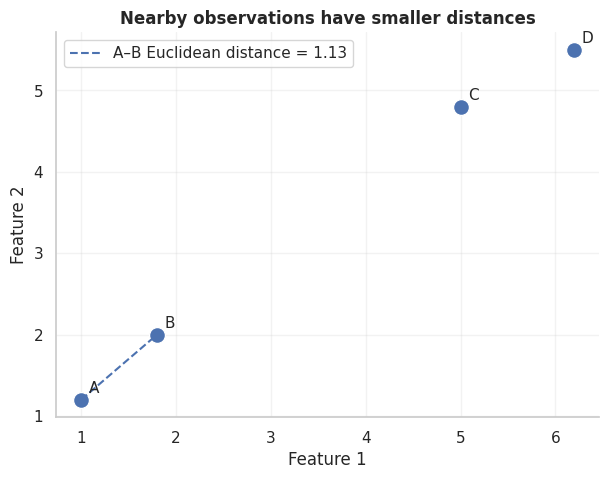

In [4]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=toy_points, x="feature_1", y="feature_2", s=130)

for _, row in toy_points.iterrows():
    plt.text(row["feature_1"] + 0.08, row["feature_2"] + 0.08, row["observation"], fontsize=11)

plt.plot(
    toy_points.loc[[0, 1], "feature_1"],
    toy_points.loc[[0, 1], "feature_2"],
    linestyle="--",
    label=f"A–B Euclidean distance = {euclidean_matrix.loc['A', 'B']:.2f}",
)
plt.title("Nearby observations have smaller distances")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

**Interpretation.** A and B are close under both measures, while A and D are far apart. The choice of distance changes the exact values and can change the resulting clusters. The definition of “similar” must match the analytical purpose.

## 3. Why scaling matters

Distance-based clustering can be dominated by variables with large numerical ranges. The next example represents customers using age and annual income. Income has much larger raw values than age, so it dominates Euclidean distance unless both variables are scaled.

In [5]:
scale_example = pd.DataFrame({
    "customer": ["A", "B", "C"],
    "age": [25, 55, 27],
    "annual_income": [50000, 51000, 90000],
})
scale_example

,customer,age,annual_income
0,A,25,50000
1,B,55,51000
2,C,27,90000


In [6]:
raw_distances = pd.DataFrame(
    squareform(pdist(scale_example[["age", "annual_income"]], metric="euclidean")),
    index=scale_example["customer"],
    columns=scale_example["customer"],
)

scaled_values = StandardScaler().fit_transform(scale_example[["age", "annual_income"]])
scaled_distances = pd.DataFrame(
    squareform(pdist(scaled_values, metric="euclidean")),
    index=scale_example["customer"],
    columns=scale_example["customer"],
)

print("Distances before scaling")
display(raw_distances.round(2))

print("Distances after standardization")
display(scaled_distances.round(2))

Distances before scaling


customer,A,B,C
customer,,,
A,0.000,"1,000.450","40,000.000"
B,"1,000.450",0.000,"39,000.010"
C,"40,000.000","39,000.010",0.000


Distances after standardization


customer,A,B,C
customer,,,
A,0.000,2.190,2.150
B,2.190,0.000,2.930
C,2.150,2.930,0.000


**Interpretation.** Before scaling, customers A and B appear very similar because their incomes are close, even though their ages differ strongly. After scaling, both variables influence the comparison. Standardization is therefore a normal preparation step before K-Means and many hierarchical methods.

## 4. Toy clustering dataset

The synthetic dataset contains three compact groups. It makes the K-Means mechanics visible before moving to a larger dataset.

In [7]:
X_toy, true_group = make_blobs(
    n_samples=240,
    centers=[(-4, 1), (0, 5), (4, 0)],
    cluster_std=[0.85, 1.00, 0.90],
    random_state=RANDOM_STATE,
)

toy_df = pd.DataFrame(X_toy, columns=["customer_value", "engagement"])
toy_df.head()

,customer_value,engagement
0,-5.631,0.977
1,1.083,6.054
2,4.308,1.689
3,4.220,-0.456
4,-1.071,5.482


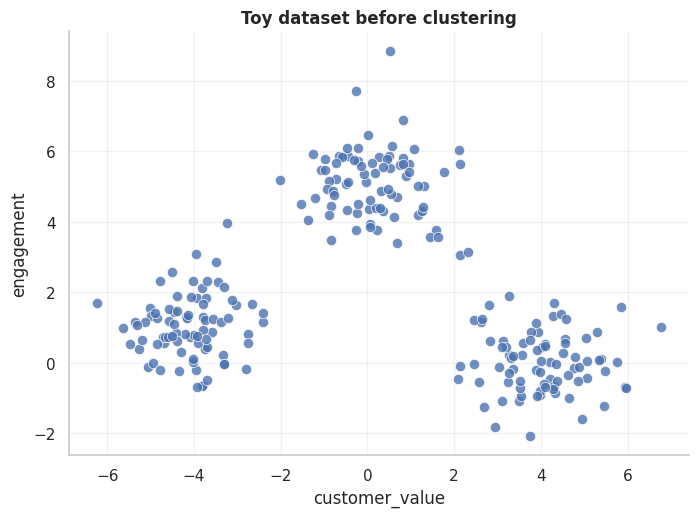

In [8]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=toy_df, x="customer_value", y="engagement", s=55, alpha=0.8)
plt.title("Toy dataset before clustering")
plt.show()

## 5. K-Means mechanics: assign points and update centroids

K-Means repeats two operations:

1. Assign every observation to its nearest centroid.
2. Recalculate each centroid as the mean of the assigned observations.

The process stops when assignments or centroid locations no longer meaningfully change.

In [9]:
# Select three starting centroids only for demonstration.
initial_centroids = toy_df.sample(3, random_state=8)[["customer_value", "engagement"]].to_numpy()

# Assign each point to its nearest starting centroid.
distance_to_centroids = cdist(toy_df, initial_centroids, metric="euclidean")
first_assignment = distance_to_centroids.argmin(axis=1)

# Recalculate centroids as cluster means.
updated_centroids = (
    toy_df.assign(cluster=first_assignment)
    .groupby("cluster")[["customer_value", "engagement"]]
    .mean()
    .sort_index()
    .to_numpy()
)

print("Initial centroids")
display(pd.DataFrame(initial_centroids, columns=toy_df.columns).round(2))

print("Centroids after one update")
display(pd.DataFrame(updated_centroids, columns=toy_df.columns).round(2))

Initial centroids


,customer_value,engagement
0,4.220,-0.460
1,-5.470,0.520
2,2.830,0.600


Centroids after one update


,customer_value,engagement
0,4.420,-0.300
1,-4.010,1.160
2,1.000,3.960


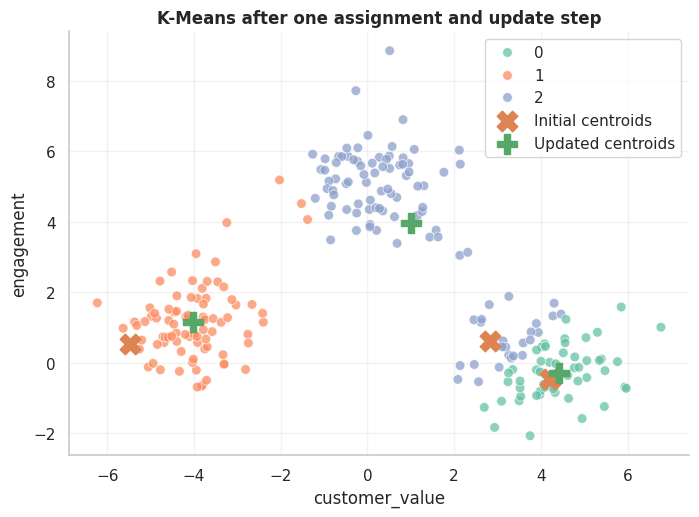

In [10]:
first_step_df = toy_df.assign(cluster=first_assignment)

plt.figure(figsize=(8, 5.5))
sns.scatterplot(
    data=first_step_df,
    x="customer_value",
    y="engagement",
    hue="cluster",
    palette="Set2",
    s=48,
    alpha=0.75,
)
plt.scatter(
    initial_centroids[:, 0],
    initial_centroids[:, 1],
    marker="X",
    s=220,
    label="Initial centroids",
)
plt.scatter(
    updated_centroids[:, 0],
    updated_centroids[:, 1],
    marker="P",
    s=190,
    label="Updated centroids",
)
plt.title("K-Means after one assignment and update step")
plt.legend()
plt.show()

**Interpretation.** The updated centroids move toward the centers of the temporary groups. A production implementation repeats these steps, uses K-Means++ initialization, and normally runs several initializations to reduce sensitivity to unlucky starting points.

## 6. Fit K-Means and inspect the final result

K-Means minimizes within-cluster sum of squares, also called inertia or WCSS. Lower inertia means observations are closer to their assigned centroids, but inertia always decreases when more clusters are added.

In [11]:
toy_kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
)
toy_df["cluster"] = toy_kmeans.fit_predict(toy_df[["customer_value", "engagement"]])

centroids = pd.DataFrame(
    toy_kmeans.cluster_centers_,
    columns=["customer_value", "engagement"],
)
centroids

,customer_value,engagement
0,-4.100,1.032
1,4.032,0.014
2,0.167,5.073


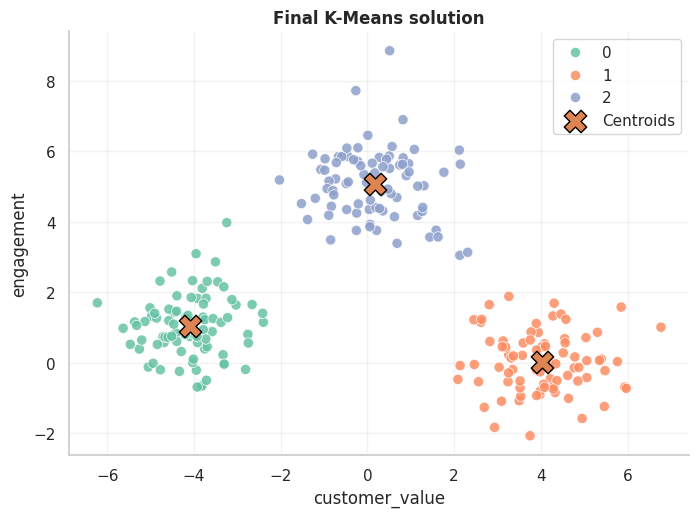

Inertia / WCSS: 384.58
Average silhouette score: 0.729


In [12]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(
    data=toy_df,
    x="customer_value",
    y="engagement",
    hue="cluster",
    palette="Set2",
    s=55,
    alpha=0.85,
)
plt.scatter(
    centroids["customer_value"],
    centroids["engagement"],
    marker="X",
    s=260,
    edgecolor="black",
    linewidth=1,
    label="Centroids",
)
plt.title("Final K-Means solution")
plt.legend()
plt.show()

print(f"Inertia / WCSS: {toy_kmeans.inertia_:,.2f}")
print(f"Average silhouette score: {silhouette_score(toy_df[['customer_value', 'engagement']], toy_df['cluster']):.3f}")

## 7. Choosing the number of clusters

No single metric supplies an unquestionable answer. A practical decision combines:

- **Elbow method:** look for diminishing improvements in WCSS.
- **Silhouette score:** higher values indicate better cohesion and separation.
- **Calinski–Harabasz index:** higher is generally better.
- **Davies–Bouldin index:** lower is generally better.
- **Interpretability and operational usefulness:** the groups must support decisions.

In [13]:
selection_rows = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(toy_df[["customer_value", "engagement"]])
    selection_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(toy_df[["customer_value", "engagement"]], labels),
        "calinski_harabasz": calinski_harabasz_score(toy_df[["customer_value", "engagement"]], labels),
        "davies_bouldin": davies_bouldin_score(toy_df[["customer_value", "engagement"]], labels),
    })

selection_df = pd.DataFrame(selection_rows)
selection_df.round(3)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,"1,754.331",0.571,329.920,0.634
1,3,384.583,0.729,"1,171.381",0.374
2,4,334.107,0.591,906.991,0.762
3,5,288.907,0.456,792.527,1.015
4,6,245.795,0.330,750.267,1.137
5,7,217.309,0.323,709.247,1.060
6,8,187.334,0.348,707.478,0.946


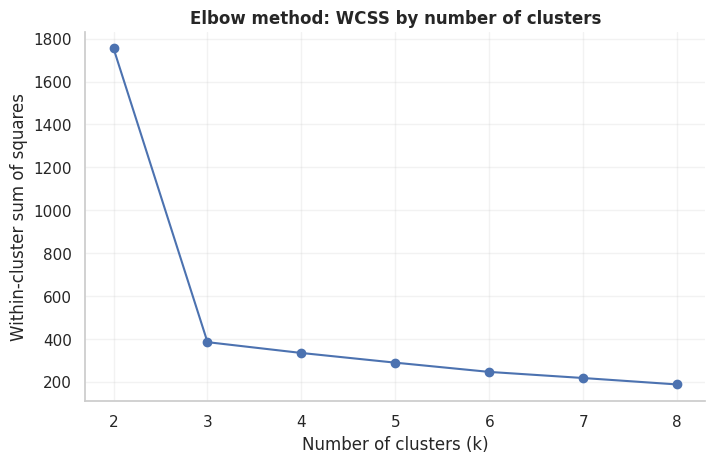

In [14]:
plt.figure(figsize=(8, 4.8))
plt.plot(selection_df["k"], selection_df["inertia"], marker="o")
plt.title("Elbow method: WCSS by number of clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares")
plt.xticks(selection_df["k"])
plt.show()

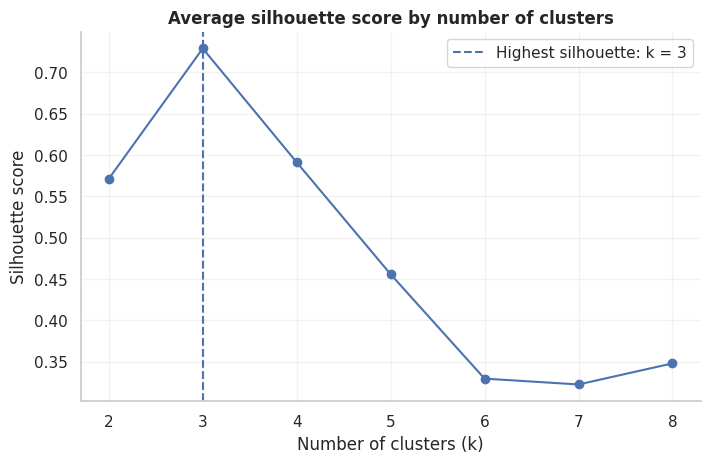

In [15]:
plt.figure(figsize=(8, 4.8))
plt.plot(selection_df["k"], selection_df["silhouette"], marker="o")
best_k_toy = int(selection_df.loc[selection_df["silhouette"].idxmax(), "k"])
plt.axvline(best_k_toy, linestyle="--", label=f"Highest silhouette: k = {best_k_toy}")
plt.title("Average silhouette score by number of clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(selection_df["k"])
plt.legend()
plt.show()

**Interpretation.** The toy data contains three well-separated groups, so the elbow and silhouette evidence should both point toward approximately three clusters. In real data, these signals are often less clear and business judgment becomes more important.

### 7.1 Silhouette values by observation

The average score can hide weakly assigned observations. A silhouette plot shows whether some observations sit near cluster boundaries.

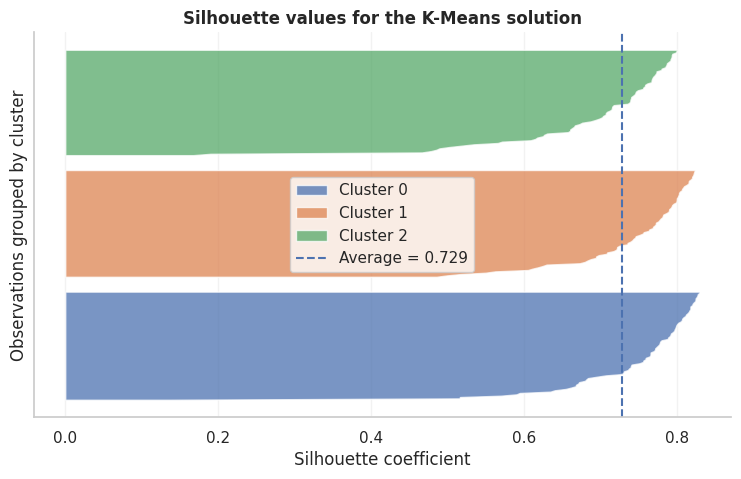

In [16]:
toy_silhouette = silhouette_samples(
    toy_df[["customer_value", "engagement"]],
    toy_df["cluster"],
)
silhouette_df = pd.DataFrame({
    "cluster": toy_df["cluster"],
    "silhouette": toy_silhouette,
}).sort_values(["cluster", "silhouette"])

plt.figure(figsize=(9, 5))
y_lower = 10

for cluster_id in sorted(silhouette_df["cluster"].unique()):
    values = silhouette_df.loc[
        silhouette_df["cluster"] == cluster_id, "silhouette"
    ].sort_values().to_numpy()
    y_upper = y_lower + len(values)
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        values,
        alpha=0.75,
        label=f"Cluster {cluster_id}",
    )
    y_lower = y_upper + 10

plt.axvline(toy_silhouette.mean(), linestyle="--", label=f"Average = {toy_silhouette.mean():.3f}")
plt.title("Silhouette values for the K-Means solution")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Observations grouped by cluster")
plt.yticks([])
plt.legend()
plt.show()

## 8. Hierarchical Clustering and the dendrogram

Agglomerative Hierarchical Clustering starts with one cluster per observation and repeatedly merges the closest clusters. A dendrogram records the merge order and distances.

The linkage rule defines the distance between groups:

- **Single linkage:** closest pair of observations.
- **Complete linkage:** farthest pair.
- **Average linkage:** average pairwise distance.
- **Ward linkage:** merge that produces the smallest increase in within-cluster variance.

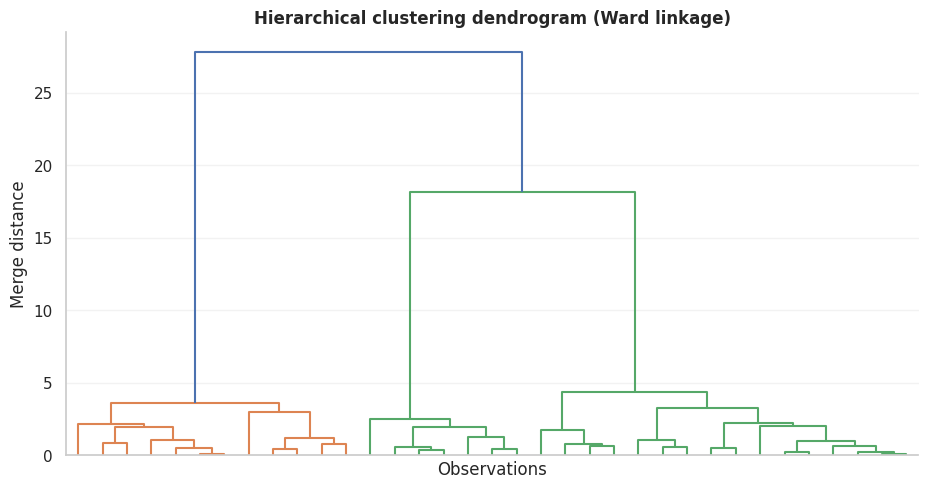

In [17]:
# Use a small sample so individual leaves remain readable.
hier_sample = toy_df.sample(35, random_state=RANDOM_STATE)[["customer_value", "engagement"]]

linkage_matrix = linkage(hier_sample, method="ward")

plt.figure(figsize=(11, 5.5))
dendrogram(linkage_matrix, no_labels=True, color_threshold=None)
plt.title("Hierarchical clustering dendrogram (Ward linkage)")
plt.xlabel("Observations")
plt.ylabel("Merge distance")
plt.show()

**How to read it.** Low merges connect very similar observations. High merges combine increasingly different groups. Drawing a horizontal line through the dendrogram and counting the branches it crosses gives a candidate number of clusters.

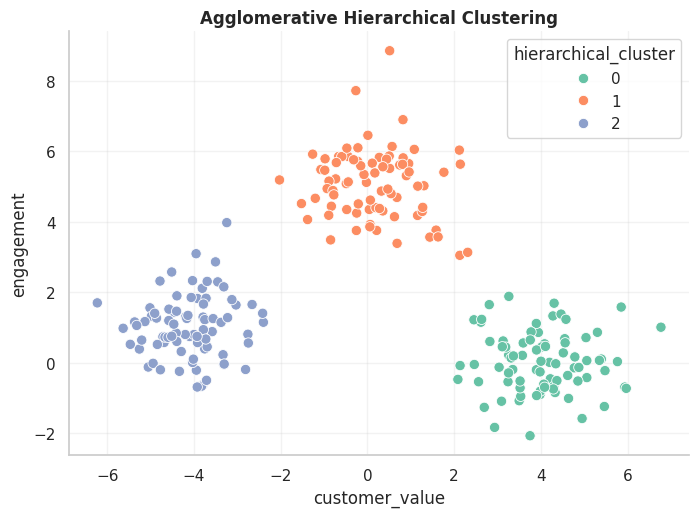

Silhouette score: 0.729


In [18]:
hierarchical_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
toy_df["hierarchical_cluster"] = hierarchical_model.fit_predict(
    toy_df[["customer_value", "engagement"]]
)

plt.figure(figsize=(8, 5.5))
sns.scatterplot(
    data=toy_df,
    x="customer_value",
    y="engagement",
    hue="hierarchical_cluster",
    palette="Set2",
    s=55,
)
plt.title("Agglomerative Hierarchical Clustering")
plt.show()

print(
    "Silhouette score:",
    round(
        silhouette_score(
            toy_df[["customer_value", "engagement"]],
            toy_df["hierarchical_cluster"],
        ),
        3,
    ),
)

## 9. Realistic example: bank customer segmentation

The provided bank dataset contains demographic and debt-related variables. The goal is exploratory segmentation, not prediction of default. Identifiers, addresses, education labels, and the default outcome are excluded from clustering so that the groups reflect numeric customer profiles rather than an existing target.

The notebook searches for `customer_bank_data.csv` in the working directory and `/mnt/data`. If the file is unavailable, it generates a compatible synthetic dataset.

In [19]:
candidate_paths = [
    Path("customer_bank_data.csv"),
    Path("/customer_bank_data.csv"),
]

bank_path = next((path for path in candidate_paths if path.exists()), None)

if bank_path is not None:
    bank_df = pd.read_csv(bank_path)
    data_source = f"Loaded {bank_path}"
else:
    rng = np.random.default_rng(RANDOM_STATE)
    n = 600
    bank_df = pd.DataFrame({
        "CUSTOMERID": np.arange(1, n + 1),
        "AGE": np.clip(rng.normal(42, 11, n), 18, 75),
        "YEARSEMPLOYED": np.clip(rng.normal(8, 6, n), 0, 35),
        "INCOME": np.clip(rng.lognormal(3.9, 0.55, n), 12, 240),
        "CARDDEBT": np.clip(rng.gamma(2.0, 1.2, n), 0, 18),
        "OTHERDEBT": np.clip(rng.gamma(2.4, 2.0, n), 0, 35),
    })
    data_source = "Generated fallback bank-style dataset"

print(data_source)
print("Shape:", bank_df.shape)
bank_df.head()

Loaded customer_bank_data.csv
Shape: (850, 9)


,CUSTOMERID,AGE,EDUCATION,YEARSEMPLOYED,INCOME,CARDDEBT,OTHERDEBT,DEFAULTED,ADDRESS
0,1,41,UNDER GRADUATE,6,19,0.124,1.073,0,NBA001
1,2,47,SCHOOL,26,100,4.582,8.218,0,NBA021
2,3,33,UNDER GRADUATE,10,57,6.111,5.802,1,NBA013
3,4,29,UNDER GRADUATE,4,19,0.681,0.516,0,NBA009
4,5,47,SCHOOL,31,253,9.308,8.908,0,NBA008


In [20]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CUSTOMERID     850 non-null    int64  
 1   AGE            850 non-null    int64  
 2   EDUCATION      850 non-null    object 
 3   YEARSEMPLOYED  850 non-null    int64  
 4   INCOME         850 non-null    int64  
 5   CARDDEBT       850 non-null    float64
 6   OTHERDEBT      850 non-null    float64
 7   DEFAULTED      850 non-null    object 
 8   ADDRESS        850 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 59.9+ KB


### 9.1 Select and prepare features

The feature set represents life stage, employment stability, purchasing power, and debt exposure. Median imputation handles missing numeric values; standardization makes the variables comparable.

In [21]:
bank_features = ["AGE", "YEARSEMPLOYED", "INCOME", "CARDDEBT", "OTHERDEBT"]

bank_model_df = bank_df[bank_features].apply(pd.to_numeric, errors="coerce")

quality_summary = pd.DataFrame({
    "dtype": bank_model_df.dtypes.astype(str),
    "missing_values": bank_model_df.isna().sum(),
    "unique_values": bank_model_df.nunique(),
    "minimum": bank_model_df.min(),
    "median": bank_model_df.median(),
    "maximum": bank_model_df.max(),
})
quality_summary

,dtype,missing_values,unique_values,minimum,median,maximum
AGE,int64,0,37,20.000,34.000,56.000
YEARSEMPLOYED,int64,0,33,0.000,7.000,33.000
INCOME,int64,0,129,13.000,35.000,446.000
CARDDEBT,float64,0,727,0.012,0.885,20.561
OTHERDEBT,float64,0,788,0.046,2.003,35.198


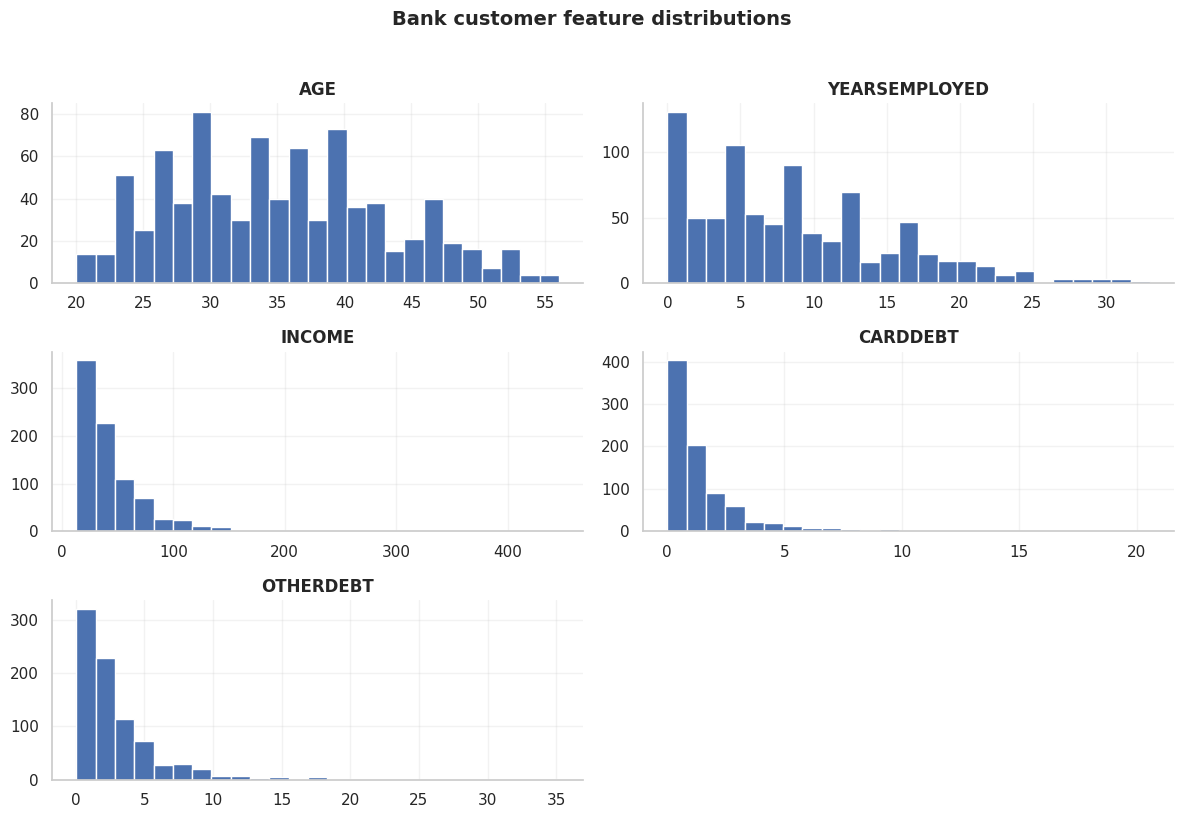

In [22]:
# Inspect distributions before scaling.
bank_model_df.hist(figsize=(12, 8), bins=25)
plt.suptitle("Bank customer feature distributions", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
preparation_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X_bank_scaled = preparation_pipeline.fit_transform(bank_model_df)
X_bank_scaled_df = pd.DataFrame(
    X_bank_scaled,
    columns=bank_features,
    index=bank_df.index,
)

X_bank_scaled_df.describe().round(2)

,AGE,YEARSEMPLOYED,INCOME,CARDDEBT,OTHERDEBT
count,850.000,850.000,850.000,850.000,850.000
mean,-0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.870,-1.260,-0.870,-0.740,-0.890
25%,-0.750,-0.820,-0.590,-0.560,-0.600
50%,-0.130,-0.230,-0.300,-0.330,-0.320
75%,0.740,0.650,0.240,0.150,0.240
max,2.610,3.610,10.370,8.940,9.460


### 9.2 Compare candidate values of K

The metrics are evidence, not automatic business decisions. A useful number of segments must also be easy to explain and operationalize.

In [24]:
bank_selection_rows = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_bank_scaled)
    bank_selection_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_bank_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_bank_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_bank_scaled, labels),
    })

bank_selection_df = pd.DataFrame(bank_selection_rows)
bank_selection_df.round(3)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,"2,713.899",0.464,479.979,1.123
1,3,"2,094.271",0.335,435.928,1.196
2,4,"1,774.028",0.295,393.581,1.264
3,5,"1,582.477",0.264,356.096,1.334
4,6,"1,426.238",0.288,334.207,1.320
5,7,"1,321.410",0.253,311.389,1.333
6,8,"1,226.345",0.283,296.574,1.212


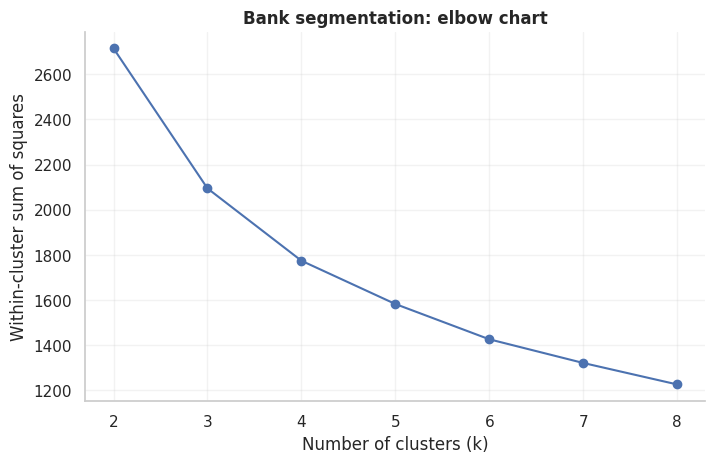

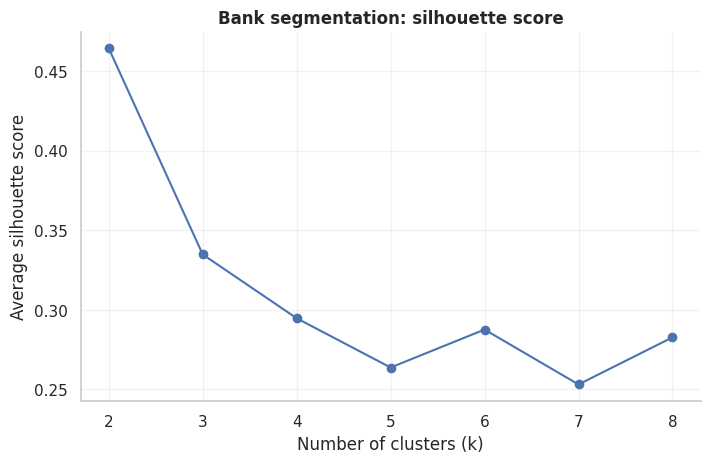

In [25]:
plt.figure(figsize=(8, 4.8))
plt.plot(bank_selection_df["k"], bank_selection_df["inertia"], marker="o")
plt.title("Bank segmentation: elbow chart")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares")
plt.xticks(bank_selection_df["k"])
plt.show()

plt.figure(figsize=(8, 4.8))
plt.plot(bank_selection_df["k"], bank_selection_df["silhouette"], marker="o")
plt.title("Bank segmentation: silhouette score")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette score")
plt.xticks(bank_selection_df["k"])
plt.show()

For demonstration, the final model uses **four clusters**. This creates a manageable set of customer profiles while still allowing meaningful differences in income, debt, age, and employment history.

In [26]:
FINAL_K = 4

bank_kmeans = KMeans(
    n_clusters=FINAL_K,
    n_init=50,
    random_state=RANDOM_STATE,
)
bank_clusters = bank_kmeans.fit_predict(X_bank_scaled)

bank_results = bank_df.copy()
bank_results["cluster"] = bank_clusters

print("Cluster sizes")
display(
    bank_results["cluster"]
    .value_counts()
    .sort_index()
    .rename("customers")
    .to_frame()
)

Cluster sizes


,customers
cluster,
0,136
1,403
2,297
3,14


### 9.3 Visualize the solution with PCA

PCA compresses the five standardized variables into two dimensions for visualization. The clustering itself still uses all five selected variables.

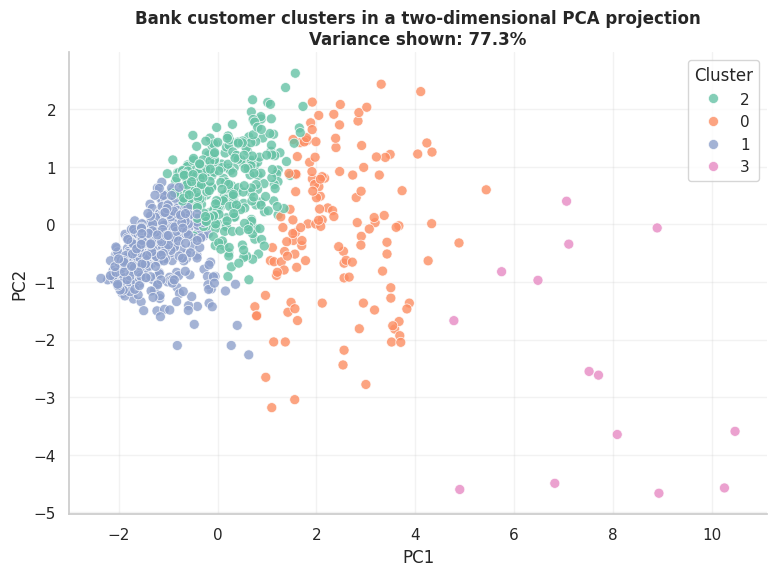

In [27]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
bank_pca = pca.fit_transform(X_bank_scaled)

bank_visual_df = pd.DataFrame({
    "PC1": bank_pca[:, 0],
    "PC2": bank_pca[:, 1],
    "cluster": bank_clusters.astype(str),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=bank_visual_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=52,
    alpha=0.8,
)
plt.title(
    "Bank customer clusters in a two-dimensional PCA projection\n"
    f"Variance shown: {pca.explained_variance_ratio_.sum():.1%}"
)
plt.legend(title="Cluster")
plt.show()

**Interpretation.** PCA is a communication aid, not proof of cluster quality. Overlap in the two-dimensional projection may occur even when separation exists across the full feature space.

### 9.4 Profile and interpret the clusters

Raw-unit profiles support business interpretation. Standardized profiles show which variables are relatively high or low compared with the full customer population.

In [28]:
raw_profile = (
    bank_results
    .groupby("cluster")[bank_features]
    .mean()
    .round(2)
)

raw_profile["customers"] = (
    bank_results.groupby("cluster").size()
)
raw_profile["share_percent"] = (
    raw_profile["customers"] / len(bank_results) * 100
).round(1)

raw_profile

,AGE,YEARSEMPLOYED,INCOME,CARDDEBT,OTHERDEBT,customers,share_percent
cluster,,,,,,,
0,41.560,16.340,91.500,3.620,7.170,136,16.000
1,28.630,4.070,26.950,0.860,1.700,403,47.400
2,40.200,10.440,45.060,1.140,2.450,297,34.900
3,46.290,22.640,213.140,11.740,16.240,14,1.600


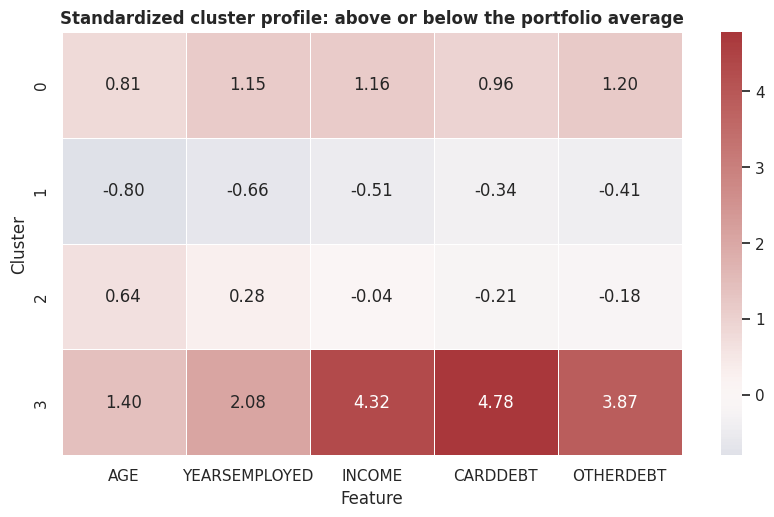

In [29]:
standardized_profile = (
    X_bank_scaled_df.assign(cluster=bank_clusters)
    .groupby("cluster")[bank_features]
    .mean()
)

plt.figure(figsize=(10, 5.5))
sns.heatmap(
    standardized_profile,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="vlag",
    linewidths=0.5,
)
plt.title("Standardized cluster profile: above or below the portfolio average")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.show()

In [30]:
# Evidence-based example labels. Review and adjust them after inspecting the profile.
def propose_segment_name(row):
    high_income = row["INCOME"] > raw_profile["INCOME"].median()
    high_debt = (row["CARDDEBT"] + row["OTHERDEBT"]) > (
        raw_profile["CARDDEBT"] + raw_profile["OTHERDEBT"]
    ).median()
    older = row["AGE"] > raw_profile["AGE"].median()
    established = row["YEARSEMPLOYED"] > raw_profile["YEARSEMPLOYED"].median()

    if high_income and established and not high_debt:
        return "Established higher-income"
    if high_income and high_debt:
        return "Higher-income, debt-exposed"
    if older and not high_income:
        return "Mature moderate-income"
    return "Younger developing profile"

segment_names = {
    cluster_id: propose_segment_name(row)
    for cluster_id, row in raw_profile.iterrows()
}

profile_with_names = raw_profile.copy()
profile_with_names.insert(
    0,
    "segment_name",
    [segment_names[idx] for idx in profile_with_names.index],
)
profile_with_names

,segment_name,AGE,YEARSEMPLOYED,INCOME,CARDDEBT,OTHERDEBT,customers,share_percent
cluster,,,,,,,,
0,"Higher-income, debt-exposed",41.560,16.340,91.500,3.620,7.170,136,16.000
1,Younger developing profile,28.630,4.070,26.950,0.860,1.700,403,47.400
2,Younger developing profile,40.200,10.440,45.060,1.140,2.450,297,34.900
3,"Higher-income, debt-exposed",46.290,22.640,213.140,11.740,16.240,14,1.600


**Business interpretation.** The names are analyst-created summaries, not algorithm outputs. They should be supported by the measured variables and reviewed with domain experts. Avoid labels such as “loyal,” “risky,” or “profitable” unless the dataset contains evidence for those concepts.

### 9.5 Validate the final solution

A balanced review considers technical quality, stability, and usefulness.

In [31]:
final_metrics = pd.DataFrame({
    "metric": [
        "Silhouette score (higher is better)",
        "Calinski–Harabasz index (higher is better)",
        "Davies–Bouldin index (lower is better)",
        "Inertia / WCSS (comparison only)",
    ],
    "value": [
        silhouette_score(X_bank_scaled, bank_clusters),
        calinski_harabasz_score(X_bank_scaled, bank_clusters),
        davies_bouldin_score(X_bank_scaled, bank_clusters),
        bank_kmeans.inertia_,
    ],
})
final_metrics

,metric,value
0,Silhouette score (higher is better),0.295
1,Calinski–Harabasz index (higher is better),393.581
2,Davies–Bouldin index (lower is better),1.264
3,Inertia / WCSS (comparison only),"1,774.028"


In [32]:
# Simple stability check: repeat K-Means with different random seeds.
stability_rows = []

for seed in range(10):
    repeated_model = KMeans(n_clusters=FINAL_K, n_init=20, random_state=seed)
    repeated_labels = repeated_model.fit_predict(X_bank_scaled)
    stability_rows.append({
        "seed": seed,
        "inertia": repeated_model.inertia_,
        "silhouette": silhouette_score(X_bank_scaled, repeated_labels),
    })

stability_df = pd.DataFrame(stability_rows)
stability_df.describe().round(4)

,seed,inertia,silhouette
count,10.000,10.000,10.000
mean,4.500,"1,774.027",0.295
std,3.028,0.002,0.000
min,0.000,"1,774.022",0.294
25%,2.250,"1,774.028",0.295
50%,4.500,"1,774.028",0.295
75%,6.750,"1,774.028",0.295
max,9.000,"1,774.028",0.295


**Interpretation.** Similar metric values across repeated initializations increase confidence that the solution is not driven by one unlucky starting point. Full stability analysis can also use bootstrap samples and compare membership consistency.

## 10. Outlier sensitivity

K-Means centroids are means, so extreme observations can pull them away from the center of the main population. Outliers should be investigated, not removed automatically: in fraud or risk analysis, unusual cases may be the most valuable observations.

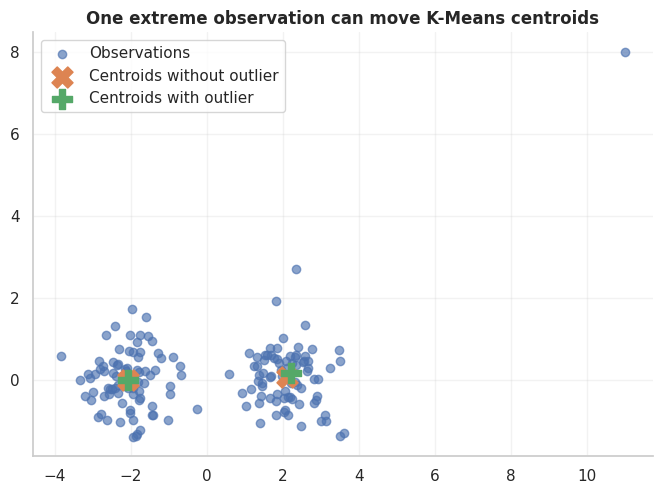

In [33]:
outlier_demo, _ = make_blobs(
    n_samples=160,
    centers=[(-2, 0), (2, 0)],
    cluster_std=0.7,
    random_state=RANDOM_STATE,
)
with_outlier = np.vstack([outlier_demo, [[11, 8]]])

model_without = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit(outlier_demo)
model_with = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE).fit(with_outlier)

plt.figure(figsize=(8, 5.5))
plt.scatter(with_outlier[:, 0], with_outlier[:, 1], alpha=0.65, label="Observations")
plt.scatter(
    model_without.cluster_centers_[:, 0],
    model_without.cluster_centers_[:, 1],
    marker="X",
    s=230,
    label="Centroids without outlier",
)
plt.scatter(
    model_with.cluster_centers_[:, 0],
    model_with.cluster_centers_[:, 1],
    marker="P",
    s=210,
    label="Centroids with outlier",
)
plt.title("One extreme observation can move K-Means centroids")
plt.legend()
plt.show()

## 11. Beyond K-Means: irregular shapes and DBSCAN

K-Means works best with compact, roughly spherical clusters of similar scale. Density-based methods such as DBSCAN can identify irregular shapes and label isolated observations as noise.

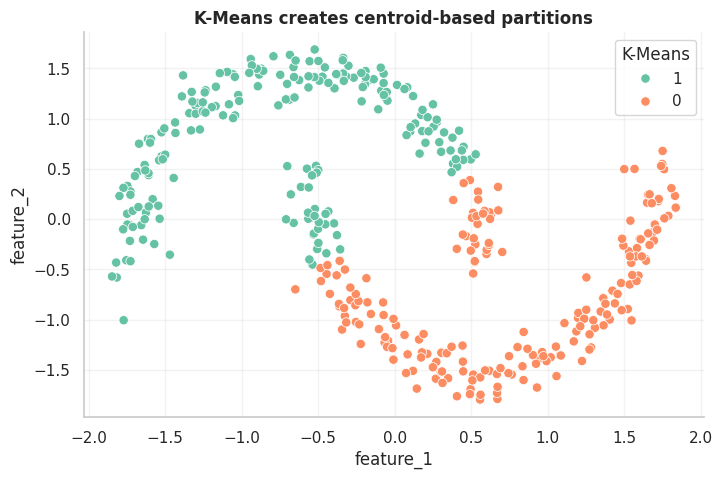

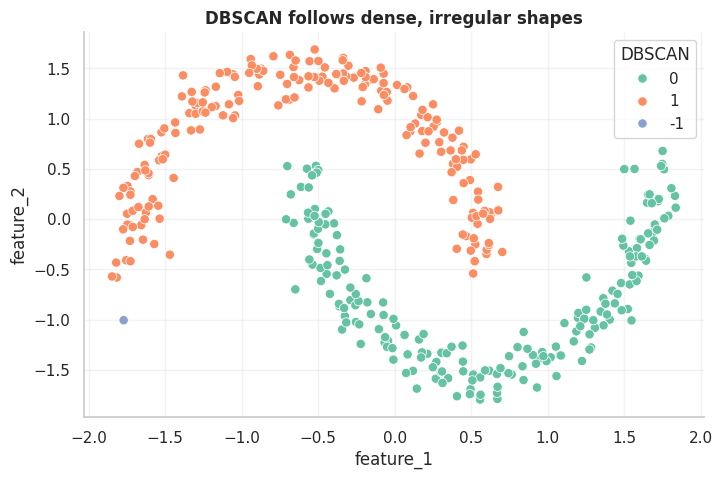

In [34]:
X_moons, _ = make_moons(n_samples=400, noise=0.07, random_state=RANDOM_STATE)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

moon_kmeans = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
moon_kmeans_labels = moon_kmeans.fit_predict(X_moons_scaled)

moon_dbscan = DBSCAN(eps=0.25, min_samples=6)
moon_dbscan_labels = moon_dbscan.fit_predict(X_moons_scaled)

comparison_df = pd.DataFrame({
    "feature_1": X_moons_scaled[:, 0],
    "feature_2": X_moons_scaled[:, 1],
    "K-Means": moon_kmeans_labels.astype(str),
    "DBSCAN": moon_dbscan_labels.astype(str),
})

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=comparison_df,
    x="feature_1",
    y="feature_2",
    hue="K-Means",
    palette="Set2",
    s=45,
)
plt.title("K-Means creates centroid-based partitions")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=comparison_df,
    x="feature_1",
    y="feature_2",
    hue="DBSCAN",
    palette="Set2",
    s=45,
)
plt.title("DBSCAN follows dense, irregular shapes")
plt.show()

**Interpretation.** There is no universally best clustering algorithm. K-Means is a strong starting point for compact groups; hierarchical methods reveal nested relationships; DBSCAN is useful for irregular shapes and noise; Gaussian mixture models are useful when probabilistic membership is more realistic.

## Common mistakes and practical safeguards

| Mistake | Why it matters | Practical safeguard |
|---|---|---|
| Forgetting to scale | Large-unit variables dominate distance | Standardize numeric features |
| Choosing K arbitrarily | Creates under- or over-segmentation | Compare elbow, silhouette, other indices, and business constraints |
| Ignoring outliers | Centroids and distances can be distorted | Investigate unusual cases and compare robust alternatives |
| Using irrelevant variables | Noise changes the meaning of similarity | Select features from the business objective |
| Treating cluster numbers as insights | `Cluster 2` has no inherent meaning | Profile, name, and validate each group |
| Trusting one metric | Technical quality may not imply usefulness | Combine metrics, stability, expert review, and actionability |
| Reading a 2D chart as the full model | PCA projections discard information | Evaluate in the complete feature space |